# Bring your own Hamiltonian

Everything in the previous notebooks went through a wrapper. But Mag$\nu$s's actual
interface is smaller than its wrapper list suggests: give it a **callable that returns a
Hermitian matrix**, and it will propagate it. The mixing parameters, the matter potential, the
BSM terms -- all of those are conveniences built on top of that one contract.

This notebook covers the contract itself, the one way of writing your `H_func` that is worth
real time, and what the Earth entry point quietly declares on your behalf.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import time
import warnings

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC))

## 1. Two contracts

**`oscprob.osc_prob(H_func, t_ini, t_fin)`** is the general one. `H_func(l)` takes a position
and returns a `(dim, dim)` Hermitian matrix. You supply everything, including the matter
potential.

**`oscprob.osc_prob_earth(H, ...)` and `osc_prob_sun(H, ...)`** are the profile-aware ones.
They know the density along the path, so they call `H(energy, l, VCC)` and hand you the
potential; you decide what to do with it. This is the interface to reach for when your new
physics lives in a *known* environment.

The dimension is read from what you return, so 2, 3, 4 and 5 flavours all work with no flag.

In [3]:
e00 = np.diag([1.0, 0.0, 0.0])          # the nu_e--nu_e slot the potential occupies

COSTHZ = -0.9
L_EARTH = earth.distance_traveled_inside_earth(COSTHZ)*gd.CONV_KM_TO_INV_EV
ENERGY = 5.0*gd.UNIT_GEV

def H_standard(energy, l, VCC):
    """Ordinary three-flavour oscillation, written out by hand."""
    return h_vac/energy + np.asarray(VCC)[..., None, None]*e00

print('P(nu_mu -> nu_mu) = %.9f'
      % oscprob.osc_prob_earth(H_standard, energy=ENERGY, costhz=COSTHZ, L=L_EARTH,
                               nu_i=gd.NUMU, nu_f=gd.NUMU))

P(nu_mu -> nu_mu) = 0.798064808


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

## 2. Write it so it accepts an array of positions

That `[..., None, None]` is the single most valuable line in this notebook.

Mag$\nu$s evaluates the Hamiltonian at many positions per slab. If your `H_func` handles an
**array** of positions in one call, it does so once per slab instead of once per point. The
indexing trick turns one potential per position into a stack of matrices, and the vacuum term
broadcasts against it for free.

Written the naive way -- `float(VCC)` and a fresh `(3,3)` -- everything still works, and
Mag$\nu$s tells you what you are paying for with a `ScalarHamiltonianWarning`.

In [4]:
def make_H(extra_ops, vectorised):
    """The same Hamiltonian, written the fast way or the slow way.

    extra_ops stands in for a genuinely expensive H_func: a table lookup, an
    interpolation, an integral.  A plain PREM density lookup is very cheap, which
    is exactly why the speed-up below grows as the Hamiltonian gets dearer."""
    def H(energy, l, VCC):
        V = np.asarray(VCC)
        for _ in range(extra_ops):
            V = V + 1.0e-30*np.sin(V*1.0e13)
        if vectorised:
            return h_vac/energy + V[..., None, None]*e00
        m = np.zeros((3, 3))
        m[0][0] = float(V)
        return h_vac/energy + m
    return H

def best_of(H, n=5):
    best = np.inf
    for _ in range(n):
        t0 = time.perf_counter()
        P = oscprob.osc_prob_earth(H, energy=ENERGY, costhz=COSTHZ, L=L_EARTH,
                                   nu_i=gd.NUMU, nu_f=gd.NUMU)
        best = min(best, time.perf_counter() - t0)
    return P, best

In [5]:
print('%-26s %10s %10s %10s %s'
      % ('H_func cost', 'scalar [s]', 'array [s]', 'speed-up', 'identical'))
print('-'*70)
for extra, label in ((0, 'plain PREM lookup'), (5, '5 extra ops/call'),
                     (50, '50 extra ops/call')):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        P_scalar, t_scalar = best_of(make_H(extra, False))
    P_array, t_array = best_of(make_H(extra, True))
    print('%-26s %10.4f %10.4f %9.2fx %s'
          % (label, t_scalar, t_array, t_scalar/t_array, P_scalar == P_array))

H_func cost                scalar [s]  array [s]   speed-up identical
----------------------------------------------------------------------
plain PREM lookup              0.0058     0.0020      2.86x True
5 extra ops/call               0.0072     0.0021      3.44x True
50 extra ops/call              0.0123     0.0030      4.08x True


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

Bit-identical output, every time -- this is a pure restructuring, not an
approximation. The gain grows with what your Hamiltonian costs, which is the point: on a bare
PREM lookup there is little to save, and on a real interpolated profile or an integral there is
a great deal. The package documentation quotes **4.6x** on a three-flavour exponential-density
profile, measured the same way.

The warning fires once per session and names the fix:

In [6]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    oscprob.osc_prob_earth(make_H(0, False), energy=ENERGY, costhz=COSTHZ,
                           L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)

for w in caught:
    if w.category is not UserWarning:
        print('%s\n' % w.category.__name__)

ScalarHamiltonianWarning



MagnusConvergenceWarning

MagnusConvergenceWarning

MagnusConvergenceWarning

MagnusConvergenceWarning



## 3. What the Earth entry point declares for you

A chord through a spherically symmetric Earth meets every radius twice, so its density profile
reads the same from either end -- it is a **palindrome**. Mag$\nu$s can then evaluate your
`H_func` on the first half of the slab chain and obtain the rest by reversal, halving the
calls.

That is geometry rather than an assumption about your input, which is why `osc_prob_earth` is
allowed to declare it (via `symmetric_over`) and a general caller is not. `osc_prob_sun` does
**not** declare it: a solar profile is monotonic, not mirror-symmetric.

The declaration is also withdrawn when it would not be true -- a request over part of a chord
rather than the whole of it is not symmetric, and is not mirrored.

It is worth what your Hamiltonian costs: 1.4--1.67x on an expensive `H_func`, and about 0.91x
on plain PREM, where halving cheap lookups does not repay the bookkeeping.
`magnus.magnus.USE_PALINDROME` disarms it globally. Notebook 24 measures this.

## 4. A worked example: a long-range force

Everything so far could have been done with a wrapper. This is the case that could not.

Suppose the Standard Model gauge group is extended by a $U(1)$ acting on $L_e - L_\mu$, with a
very light mediator $Z'$ (following [arXiv:1808.02042](https://arxiv.org/abs/1808.02042)).
Electrons carry $L_e = 1$, so ordinary matter sources the new field; among the neutrinos
$\nu_e$ carries $+1$, $\nu_\mu$ carries $-1$, and $\nu_\tau$ is neutral. The Hamiltonian
becomes

$$\mathbf{H} = \underbrace{\frac{\mathbf{H}_{\rm vac}}{E}
   + V_{\rm CC}\,{\rm diag}(1,0,0)}_{\text{the standard part}}
   \;+\; V_{e\mu}(r)\,{\rm diag}(1,-1,0),$$

with the new potential a Yukawa integral over **all** the electrons of the body,

$$V_{e\mu}(\mathbf{r}) = \frac{g'^2}{4\pi}\int d^3r'\;
   n_e(\mathbf{r}')\,\frac{e^{-m_{Z'}|\mathbf{r}-\mathbf{r}'|}}{|\mathbf{r}-\mathbf{r}'|}.$$

**That matrix is the reason this notebook exists.** It is not
$\mathbf{H}_{\rm vac}/E + V_{\rm CC}\mathbf{P}_{ee}$ for any choice of $V_{\rm CC}$, so no
amount of arguing with `osc_prob_3nu_earth` will produce it -- the flavour structure
${\rm diag}(1,-1,0)$ is not in that function's vocabulary. And unlike $V_{\rm CC}$, which reads
the density at the neutrino's own position, $V_{e\mu}$ integrates the whole body: it varies
along the trajectory for reasons that have nothing to do with the local density.

### The integral is one-dimensional

A three-dimensional integral per slab would be hopeless. But for a spherically symmetric $n_e$
the angular average of the Yukawa kernel over a shell is elementary, and the result separates
into an interior and an exterior piece:

$$V_{e\mu}(r) = \frac{g'^2}{r}\,e^{-mr}\!\int_0^r\! dr'\,r'^2 n_e(r')\,{\rm shc}(mr')
  \;+\; g'^2\,{\rm shc}(mr)\!\int_r^R\! dr'\,r'\,n_e(r')\,e^{-mr'},$$

with ${\rm shc}(x) \equiv \sinh(x)/x$, which is $1$ at the origin.

Two consequences, and both matter. The $r$-dependence has left the integrands, so **one pass
over the profile serves every point on the trajectory** -- the potential is built once per
body, not once per slab. And nothing diverges as $m \to 0$.

In [7]:
def running_integral(y, x):
    """Trapezoidal running integral of y over x, zero at the first node.

    Spelled out rather than imported: numpy has no cumulative trapezoid, and
    the plain one changed name in NumPy 2.0 (np.trapz was removed in favour of
    np.trapezoid), so neither spelling is portable.  This is one cumsum, works
    on every version, and keeps the example to plain numpy."""
    return np.concatenate([[0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))])


def shc(x):
    """sinh(x)/x, continued to 1 at the origin."""
    x = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    big = np.abs(x) > 1.0e-8
    out[big] = np.sinh(x[big])/x[big]
    return out

def long_range_potential(r_grid, ne_grid, m):
    """V_{e-mu}(r) on r_grid, in units of g'^2, for a spherical n_e(r).

    Two cumulative integrals over the profile, evaluated once.  Everything the
    trajectory then needs is a lookup."""
    inner = r_grid**2*ne_grid*shc(m*r_grid)
    outer = r_grid*ne_grid*np.exp(-m*r_grid)
    I_in = running_integral(inner, r_grid)
    running_out = running_integral(outer, r_grid)
    I_out = running_out[-1] - running_out          # the exterior piece, r' > r
    r_safe = np.where(r_grid > 0.0, r_grid, 1.0e-30)
    return np.exp(-m*r_grid)*I_in/r_safe + shc(m*r_grid)*I_out

### Does the potential come out right?

A uniform ball has a closed form at **any** mediator mass,

$$V_{e\mu}(r) = \frac{g'^2 n_e}{m^2}
  \left[1 - \left(R + \frac{1}{m}\right)e^{-mR}\,\frac{\sinh(mr)}{r}\right],$$

so this is a check against something external rather than a self-consistency test. Worth doing
before any physics: a quadrature that is quietly wrong produces figures that look entirely
reasonable.

In [8]:
R_E = gd.EARTH_RADIUS                       # [km]
r_uniform = np.linspace(0.0, R_E, 200001)
ne_uniform = np.ones_like(r_uniform)

print('%-14s %s' % ('1/m', 'max relative error vs the closed form'))
print('-'*52)
for inverse_m in (0.05, 0.3, 1.0, 5.0):
    m = 1.0/(inverse_m*R_E)
    numeric = long_range_potential(r_uniform, ne_uniform, m)
    r_safe = np.where(r_uniform > 0.0, r_uniform, 1.0e-30)
    closed = (1.0/m**2)*(1.0 - (R_E + 1.0/m)*np.exp(-m*R_E)
                         * np.where(r_uniform > 0.0, np.sinh(m*r_safe)/r_safe, m))
    print('%-14s %.2e' % ('%.2f R' % inverse_m,
                          np.max(np.abs(numeric - closed)/np.abs(closed))))

1/m            max relative error vs the closed form
----------------------------------------------------
0.05 R         5.11e-08
0.30 R         4.29e-11
1.00 R         1.54e-11
5.00 R         1.26e-11


### The mediator's range decides what the potential looks like

Now the Earth's own electrons, from PREM. The density **jumps** at each shell boundary, so the
quadrature grid must put a node on every one -- the same rule that makes `t_breakpoints`
necessary for the propagation itself (notebook 18).

Two limits are worth holding in mind:

* **Short range**, $1/m \ll R$: only the neighbourhood contributes and
  $V_{e\mu} \to g'^2 n_e(r)/m^2$. The potential tracks the *local* density, which makes it
  degenerate with an NSI -- notebook 08's $\epsilon_{\alpha\beta}$ with a particular flavour
  structure.
* **Long range**, $1/m \gg R$: the whole body contributes, and the potential is smooth,
  largest at the centre, and indifferent to where any individual electron sits.

Only the second is genuinely new as far as this package is concerned, and only the second
needs the profile machinery at all.

In [9]:
prem_edges = np.concatenate(([0.0], earth.PREM_BOUNDARIES))
r_prem = np.unique(np.concatenate(
    [np.linspace(a, b, 900) for a, b in zip(prem_edges[:-1], prem_edges[1:])]))
ne_prem = matter.num_density_e_func(r_prem, earth.density_matter_func_prem,
                                    electron_fraction=0.5,
                                    density_matter_is_in_g_per_cm3=True)

print('grid: %d nodes, with one on every PREM boundary' % len(r_prem))
print('%-12s %-14s %s' % ('1/m', 'V(0)/V(R)', 'V(0)'))
print('-'*42)
V_ranges = {}
for inverse_m in (0.03, 0.3, 1.0, 10.0):
    V = long_range_potential(r_prem, ne_prem, 1.0/(inverse_m*R_E))
    V_ranges[inverse_m] = V
    print('%-12s %-14.3f %.4e' % ('%.2f R' % inverse_m, V[0]/V[-1], V[0]))

print('\nfor reference, the density contrast n_e(0)/n_e(R) = %.3f'
      % (ne_prem[0]/ne_prem[-1]))

grid: 8092 nodes, with one on every PREM boundary
1/m          V(0)/V(R)      V(0)
------------------------------------------
0.03 R       7.913          1.0926e+15
0.30 R       4.600          6.5479e+16
1.00 R       2.632          1.8012e+17
10.00 R      1.865          2.8925e+17

for reference, the density contrast n_e(0)/n_e(R) = 5.034


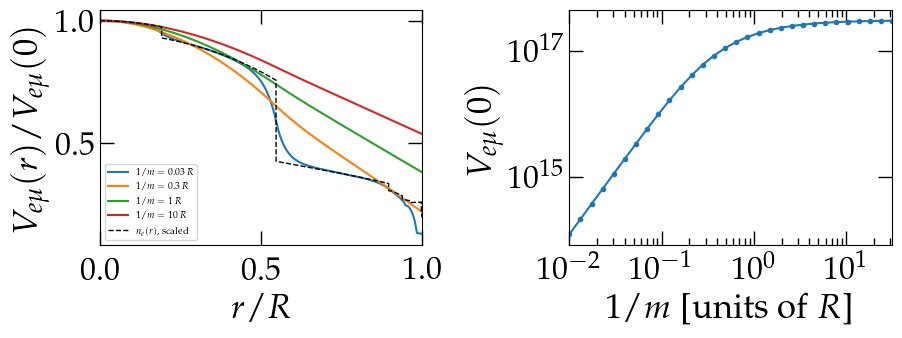

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.4, 3.6))

for inverse_m, V in V_ranges.items():
    axL.plot(r_prem/R_E, V/V[0], label=r'$1/m = %g\,R$' % inverse_m)
axL.plot(r_prem/R_E, ne_prem/ne_prem[0], 'k--', lw=1.0, label=r'$n_e(r)$, scaled')
axL.set_xlabel(r'$r / R$')
axL.set_ylabel(r'$V_{e\mu}(r) / V_{e\mu}(0)$')
axL.legend(fontsize=7)
axL.set_xlim(0.0, 1.0)

inv = np.logspace(-2.0, 1.5, 30)
centre = [long_range_potential(r_prem, ne_prem, 1.0/(v*R_E))[0] for v in inv]
axR.loglog(inv, centre, marker='o', ms=3)
axR.set_xlabel(r'$1/m$  [units of $R$]')
axR.set_ylabel(r'$V_{e\mu}(0)$')
axR.set_xlim(inv[0], inv[-1])
fig.tight_layout()

The left panel is the whole argument in one picture. At $1/m = 0.03\,R$ the potential
has nearly taken the shape of the dashed density curve, shell jumps and all; by $1/m = 10\,R$
it has forgotten the profile entirely and is a smooth bowl. The right panel shows the
crossover: $V_{e\mu}(0)$ grows as $1/m^2$ while the range is short, and saturates once the
mediator reaches across the body, because there are no more electrons left to enclose.

### Through the Earth

Now put it in a Hamiltonian and propagate. The potential is a lookup against the pass computed
above, so the cost of the new physics is one interpolation per position.

In [11]:
INVERSE_M = 1.0                            # the awkward middle: 1/m = R
V_LRF = long_range_potential(r_prem, ne_prem, 1.0/(INVERSE_M*R_E))
lrf_charge = np.diag([1.0, -1.0, 0.0])     # the L_e - L_mu charge

# g'^2 chosen so the new potential is a tenth of V_CC at the centre: small
# enough to be plausible, large enough to see.
VCC_centre = matter.VCC_func(0.0, lambda l: ne_prem[0])
G_SQUARED = 0.1*VCC_centre/V_LRF[0]

def H_long_range(energy, l, VCC):
    """Standard oscillation plus the long-range term, both position dependent."""
    r = earth.earth_radial_distance_from_depth(
        COSTHZ, np.asarray(l)/gd.CONV_KM_TO_INV_EV)
    V_new = G_SQUARED*np.interp(r, r_prem, V_LRF)
    return (h_vac/energy
            + np.asarray(VCC)[..., None, None]*e00
            + np.asarray(V_new)[..., None, None]*lrf_charge)

E_gev = np.logspace(-0.3, 1.5, 300)
E_scan = E_gev*gd.UNIT_GEV

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    p_std = oscprob.osc_prob_earth(H_standard, energy=E_scan, costhz=COSTHZ,
                                   L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)
    p_lrf = oscprob.osc_prob_earth(H_long_range, energy=E_scan, costhz=COSTHZ,
                                   L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)

gap = np.abs(np.asarray(p_std) - np.asarray(p_lrf))
print('V_new(0) is 10%% of V_CC there')
print('max |standard - long range| = %.4f  at %.2f GeV'
      % (gap.max(), E_gev[gap.argmax()]))

V_new(0) is 10%% of V_CC there
max |standard - long range| = 0.6332  at 3.54 GeV


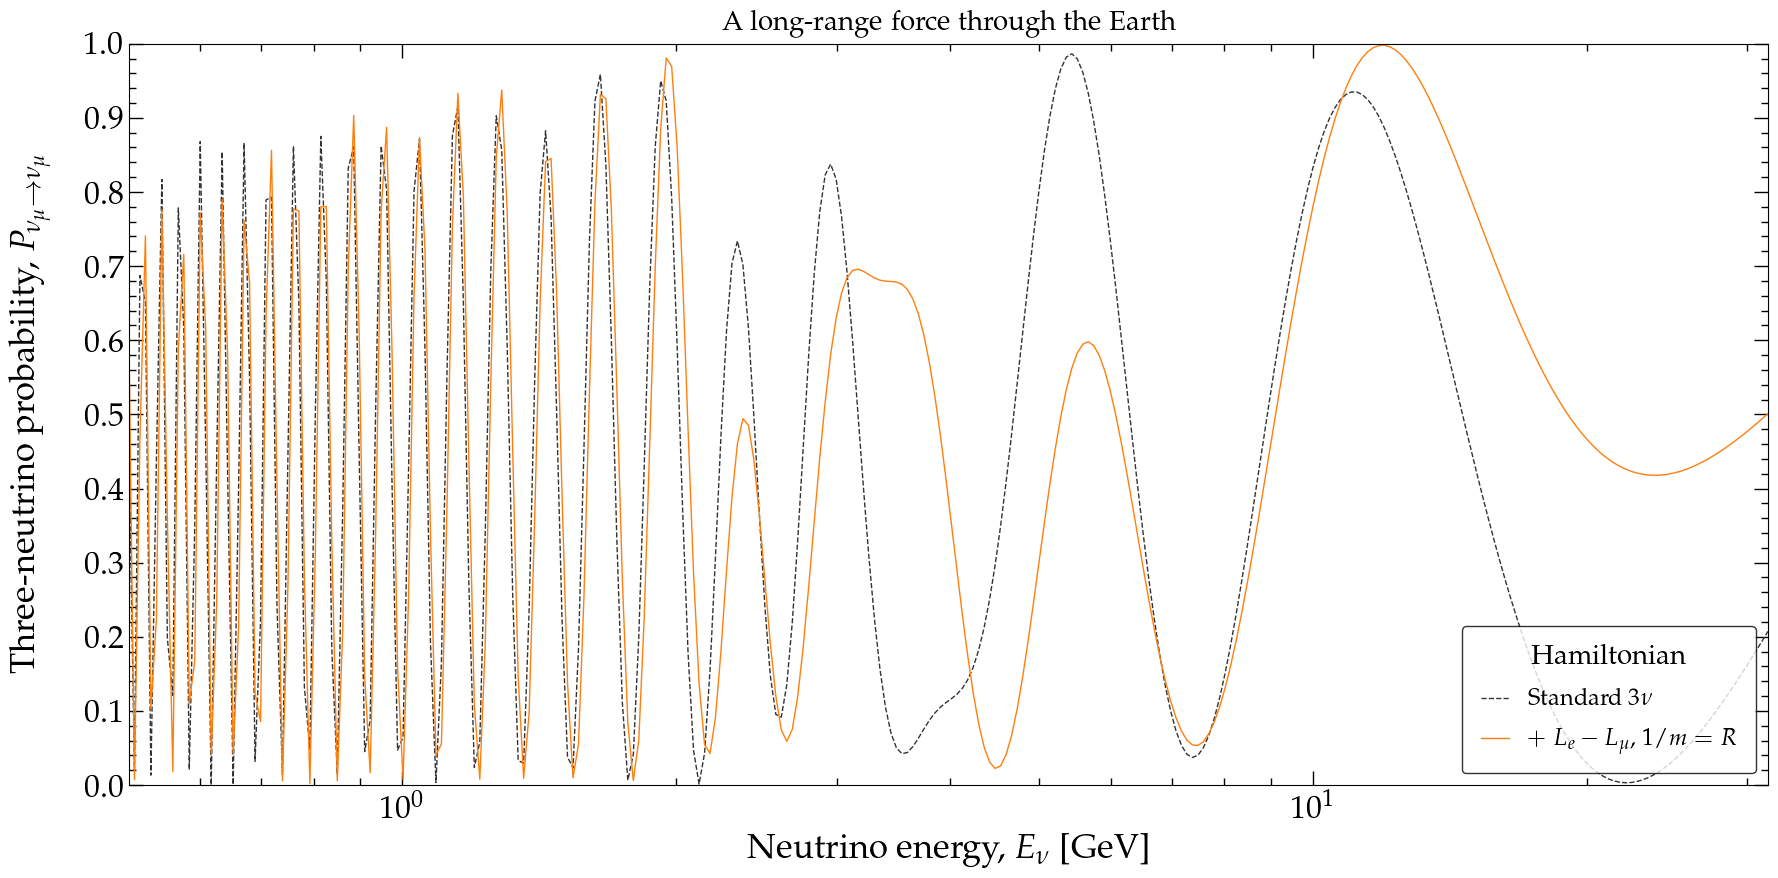

In [12]:
fig, ax = plotting.plot_probability_vs_energy(
    E_gev,
    [dict(y=np.asarray(p_std), label=r'Standard $3\nu$', color='0.2', ls='--'),
     dict(y=np.asarray(p_lrf), label=r'$+\;L_e - L_\mu$, $1/m = R$', color='C1')],
    nu_i=gd.NUMU, nu_f=gd.NUMU, num_flavors=3,
    xlim=(E_gev[0], E_gev[-1]),
    legend_title='Hamiltonian', legend_loc='lower right',
    title=r'A long-range force through the Earth')

The shift is not a rescaling of the standard curve: the new term has a different
flavour structure, so it moves the oscillation rather than damping it.

Everything the package needed from you was a callable. What it gave back was the whole slab
machinery -- adaptive refinement, the palindrome, the engine dispatch of notebook 22 -- applied
to a Hamiltonian it has never seen.

## Summary -- a checklist for your own `H_func`

1. **Return a Hermitian matrix.** The dimension is inferred; 2 to 5 flavours need no flag.
2. **Accept an array of positions**, and use `np.asarray(VCC)[..., None, None]` to build the
   stack. Bit-identical results, and the gain grows with what your Hamiltonian costs.
3. **Take the matter potential from the entry point** (`osc_prob_earth`/`osc_prob_sun`) or
   from `matter.vcc_func_from_rho_func`. For antineutrinos pass `nubar=True` there and do not
   negate it again -- notebook 15.
4. **Declare discontinuities** with `t_breakpoints`. A slab straddling a jump is not fixed by
   refinement -- notebook 18.
5. **Do not declare symmetry yourself.** `osc_prob_earth` does it where geometry guarantees it.

If you want to know which engine then answered your request, and whether to believe it, that
is notebooks 21 and 22.

---

**Previous:** [Unusual density profiles](18_magnus_unusual_density_profiles.ipynb)  
**Next:** [Numerical edge cases](20_magnus_numerical_edge_cases.ipynb) --- degeneracies that return numbers, and what the nine warnings mean  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)